# Commodity Anomaly Detection — Isolation Forest & Changepoint Detection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.ensemble import IsolationForest
import ruptures as rpt

from project_config import TICKERS, ROLL_WINDOW, Z_THRESHOLD, MAD_SCALE, ANNUALISATION, IF_CONTAMINATION, rolling_mad

%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = True


## 1. Load data and rebuild baseline features

In [2]:
DATA_DIR = Path("data")

dfs = {}
for key in TICKERS:
    df = pd.read_csv(DATA_DIR / f"{key}.csv", index_col="date", parse_dates=True)
    dfs[key] = df

# Simple returns (pct_change), not log returns — WTI crude traded negative on 2020-04-20,
# and log() of a negative price is undefined. Log returns would silently NaN-out and drop
# that day, hiding the most extreme anomaly in the oil series.
returns = {}
for key in TICKERS:
    close = dfs[key]["Close"]
    returns[key] = close.pct_change().dropna()

vol = {}
for key in TICKERS:
    r = returns[key]
    vol[key] = pd.DataFrame({
        "vol_10d": r.rolling(10).std() * ANNUALISATION,
        "vol_30d": r.rolling(30).std() * ANNUALISATION,
    })

# Robust (MAD-based) rolling z-score baseline — see EDA notebook, section 7, for why median/MAD
# is used instead of mean/std (a single extreme value distorts std for weeks afterward) and for
# the threshold sweep that justifies Z_THRESHOLD's value in project_config.py.
z_flags = {}
for key in TICKERS:
    r = returns[key]
    roll_median = r.rolling(ROLL_WINDOW).median()
    roll_mad = rolling_mad(r, ROLL_WINDOW) * MAD_SCALE
    z_robust = (r - roll_median) / roll_mad.replace(0, np.nan)
    z_flags[key] = set(r[z_robust.abs() > Z_THRESHOLD].index)
    print(f"{TICKERS[key]}: {len(z_flags[key])} baseline z-score flags "
          f"({len(z_flags[key]) / len(r) * 100:.1f}% of days)")


Gold (GC=F): 38 baseline z-score flags (1.3% of days)
Silver (SI=F): 48 baseline z-score flags (1.6% of days)
WTI Crude (CL=F): 39 baseline z-score flags (1.3% of days)


## 2. Isolation Forest — multivariate point anomalies

In [3]:
if_flags = {}
if_scores = {}

for key in TICKERS:
    feat_df = pd.DataFrame({
        "return": returns[key],
        "vol_10d": vol[key]["vol_10d"],
        "vol_30d": vol[key]["vol_30d"],
    }).dropna()

    iso = IsolationForest(n_estimators=200, contamination=IF_CONTAMINATION, random_state=42)
    preds = iso.fit_predict(feat_df)
    scores = iso.decision_function(feat_df)  # lower score = more anomalous

    if_flags[key] = set(feat_df.index[preds == -1])
    if_scores[key] = pd.Series(scores, index=feat_df.index)

    print(f"{TICKERS[key]}: {len(if_flags[key])} Isolation Forest flags")


Gold (GC=F): 59 Isolation Forest flags
Silver (SI=F): 59 Isolation Forest flags
WTI Crude (CL=F): 59 Isolation Forest flags


## 3. `ruptures` — changepoint / regime detection

Applied to a **robust (MAD-based) rolling volatility** signal, not the plain std-based
`vol_30d` from section 1. Reason: `vol_30d` is itself a rolling std, so it inherits the same
single-outlier sensitivity discussed in the EDA notebook — WTI's 2020-04-20 shock would
dominate the changepoint signal for weeks afterward, which risks `ruptures` reacting to one
day's aftermath rather than identifying a genuine, persistent regime shift.

Using Pelt with an RBF cost function (no need to pre-specify the number of changepoints).
`pen` (penalty) controls sensitivity — higher = fewer, more conservative changepoints. Start at
15 and adjust based on the plot below (too many changepoints = raise it; missing obvious
regime shifts = lower it).

In [4]:
PEN = 15

robust_vol = {}
changepoints = {}
for key in TICKERS:
    r = returns[key]
    robust_vol[key] = (rolling_mad(r, 30) * MAD_SCALE * ANNUALISATION).dropna()

    signal = robust_vol[key].values.reshape(-1, 1)
    algo = rpt.Pelt(model="rbf", min_size=30, jump=5).fit(signal)
    bkps = algo.predict(pen=PEN)

    # ruptures returns breakpoint indices with the final one = len(signal); drop it
    changepoints[key] = [robust_vol[key].index[i - 1] for i in bkps[:-1]]
    print(f"{TICKERS[key]}: {len(changepoints[key])} changepoints detected")


Gold (GC=F): 19 changepoints detected
Silver (SI=F): 22 changepoints detected
WTI Crude (CL=F): 27 changepoints detected


## 4. Agreement check: does Isolation Forest just rediscover the z-score flags?

In [5]:
comparison = []
for key in TICKERS:
    z_set = z_flags[key]
    if_set = if_flags[key]
    overlap = z_set & if_set
    z_rate_pct = len(z_set) / len(returns[key]) * 100

    comparison.append({
        "commodity": TICKERS[key],
        "z_score_flags": len(z_set),
        "z_score_flag_rate_pct": round(z_rate_pct, 1),
        "isolation_forest_flags": len(if_set),
        "if_contamination_pct": round(IF_CONTAMINATION * 100, 1),
        "overlap": len(overlap),
        "pct_of_zscore_also_caught_by_IF": round(len(overlap) / len(z_set) * 100, 1) if z_set else np.nan,
        "IF_only_flags (novel)": len(if_set - z_set),
    })

pd.DataFrame(comparison)


,commodity,z_score_flags,z_score_flag_rate_pct,isolation_forest_flags,if_contamination_pct,overlap,pct_of_zscore_also_caught_by_IF,IF_only_flags (novel)
0,Gold (GC=F),38,1.3,59,2.0,8,21.1,51
1,Silver (SI=F),48,1.6,59,2.0,7,14.6,52
2,WTI Crude (CL=F),39,1.3,59,2.0,16,41.0,43


If `z_score_flag_rate_pct` and `if_contamination_pct` are close for a commodity, the 2%
assumption is a reasonable match there. If they diverge a lot (e.g. the baseline naturally
flags ~1% of oil's days but Isolation Forest is forced to flag 2%), consider setting
`contamination` per-commodity in section 2 rather than using one fixed value for all three.

In [6]:
# Look at a handful of the "novel" Isolation Forest flags — days it caught that the
# simple return z-score missed. These are the ones worth understanding for the writeup.
for key in TICKERS:
    novel = sorted(if_flags[key] - z_flags[key])
    if novel:
        print(f"\n{TICKERS[key]} — sample of IF-only flags (return z-score missed these):")
        sample = returns[key].loc[novel].sort_values(key=abs, ascending=False).head(5)
        print(sample)



Gold (GC=F) — sample of IF-only flags (return z-score missed these):
date
2026-03-19   -0.059332
2026-03-26   -0.038662
2025-04-23   -0.036644
2026-03-23   -0.036635
2026-04-01    0.035610
Name: Close, dtype: float64

Silver (SI=F) — sample of IF-only flags (return z-score missed these):
date
2026-01-26    0.140253
2025-12-30    0.107621
2026-02-12   -0.098001
2025-12-31   -0.093571
2026-05-15   -0.091283
Name: Close, dtype: float64

WTI Crude (CL=F) — sample of IF-only flags (return z-score missed these):
date
2020-05-05    0.204512
2026-04-17   -0.114479
2020-04-14   -0.102633
2020-04-07   -0.093942
2020-04-09   -0.092866
Name: Close, dtype: float64


## 5. Visual comparison — all three detectors on one chart

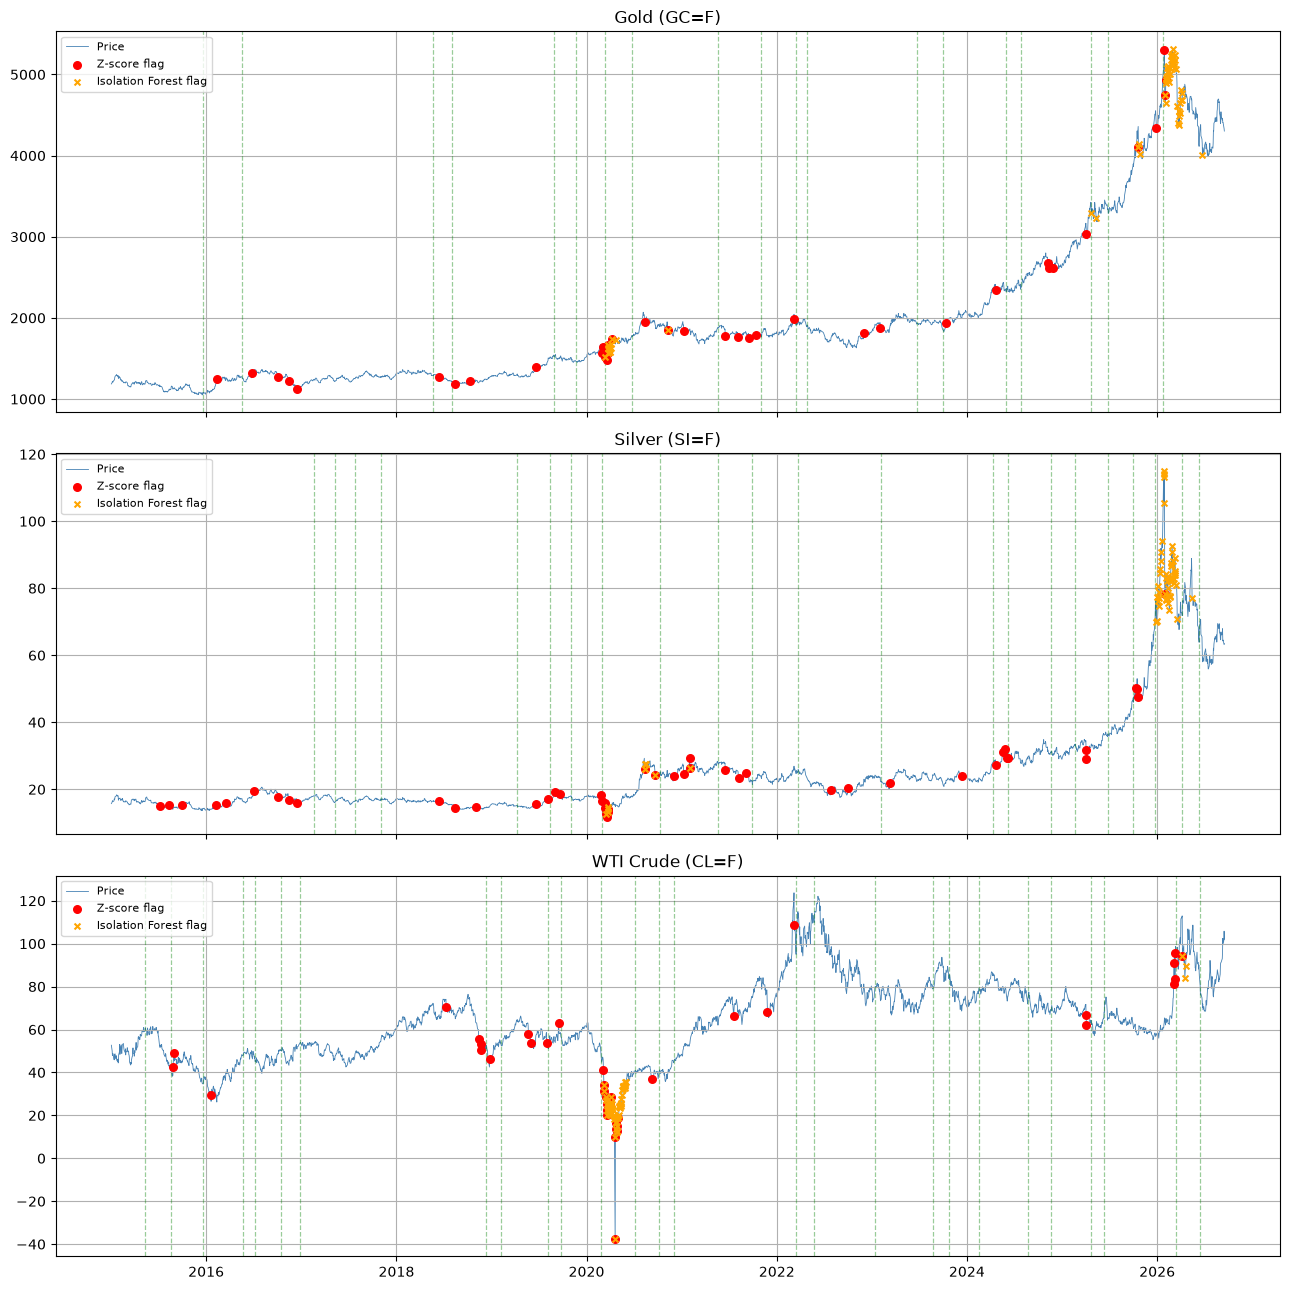

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(13, 13), sharex=True)

for ax, (key, label) in zip(axes, TICKERS.items()):
    close = dfs[key]["Close"]
    ax.plot(close.index, close, linewidth=0.6, color="steelblue", label="Price", zorder=1)

    z_dates = sorted(z_flags[key])
    ax.scatter(z_dates, close.loc[z_dates], color="red", s=30, zorder=5, label="Z-score flag")

    if_dates = sorted(if_flags[key])
    ax.scatter(if_dates, close.loc[if_dates], color="orange", s=18, marker="x", zorder=6, label="Isolation Forest flag")

    for cp in changepoints[key]:
        ax.axvline(cp, color="green", linestyle="--", alpha=0.4, linewidth=0.9)

    ax.set_title(label)
    ax.legend(loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()
